In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Coding the entire Neural Network with forward & Backward pass

### Creating a Layer with forward & backward pass

In [22]:
class layer_dense:
    def __init__(self,n_inputs,n_neurons):
        self.weights = 0.01*np.random.randn(n_inputs,n_neurons)
        self.biases = np.zeros(1,n_neurons)
        
    def forward(self,inputs):
        self.inputs = inputs
        self.outputs = np.dot(inputs,self.weights)+self.biases
        
    def backward(self,dvalues):
        self.dvalues = dvalues
        # Gradients on parameters
        self.weights = np.dot(self.inputs.T,dvalues)
        self.biases = np.sum(dvalues,axis = 0,keepdims=True)
        # Gradients on Values
        self.inputs = np.dot(dvalues,self.weights.T)

### ReLu Activation: Forward & Backward pass

In [23]:
class Activation_relu:
    # relu activation function
    def forward(self,inputs):
        self.inputs = inputs
        self.output = np.maximum(inputs,0)
    
    # Backward pass
    def backward(self,dvalues):
        self.dinputs = dvalues.copy
        self.dinputs[self.inputs<=0] = 0

### Softmax Activation: Forward Pass

In [24]:
class activation_softmax:
    def forward(self,inputs):
        self.inputs = inputs
        # get unnormalized probabilities
        exp_values = np.exp(inputs-np.max(inputs,axis=1,keepdims=True))
        # getting normalize for each sample
        probability = exp_values / np.sum(exp_values,axis=1,keepdims=True)
        self.ouputs = probability

### Loss Class

In [25]:
class Loss:
    def calculate(self,outputs,y):
        sample_loss = np.forward(output,y)
        data_loss = np.mean(sample_loss)
        return data_loss

In [26]:
class Loss_CategoricalCrossEntropy(Loss):
    def forward(self,y_pred,y_true):
        # No. of samples in a batch
        samples = len(y_pred)
        # Clip data to prevent division by 0
        # Clip both sides to not drag mean towards any value
        y_pred_clipped = np.clip(y_pred,1e-7,1-1e-7)
        
        # Prob for target values- only if categorical values
        if len(y_true.shape)==1:
            correction_score = y_pred_clipped[
                range(samples),
                y_true
            ]
        # Mask values only for one hot coded labels
        elif len(y_true.shape)==2:
            correction_score = np.sum(y_pred_clipped*y_true,axis=1)
            
        # Losses
        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods
    
    # Backward Pass
    def backward(self,dvalues,y_true):
        # Number of samples
        samples = len(dvalues)
        # No of labels
        # use first sample to count them
        labels = len(dvalues[0])
        
        # if labels are sparse,turn them into one hot vector
        if len(y_true.shape)==1:
            y_true = np.eye(labels)[y_true]
        
        # calculate gradients
        self.dinputs = -y_true / dvalues
        # Normalize 
        self.dinputs = dinputs / samples

### COMBINED SOFTMAX ACTIVATION AND CATEGORICAL CROSS ENTROPY FOR LAST LAYER: FORWARD AND BACKWARD PASS

In [27]:
class Activation_softmax_loss_categoricalCrossEntropy:
    # softmax and loss function objects
    def __init__(self):
        self.softmax = activation_softmax()
        self.loss = Loss_CategoricalCrossEntropy()
    
    def forward(self,inputs,y_true):
        self.softmax.forward(inputs)
        self.ouputs = self.softmax.outputs
        return self.loss.calculate(self.outputs,y_true)
    
   # Backward pass
    def backward(self, dvalues, y_true):
        # Number of samples
        samples = len(dvalues)
        # If labels are one-hot encoded,
        # turn them into discrete values
        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)
        # Copy so we can safely modify
        self.dinputs = dvalues.copy()
        # Calculate gradient
        self.dinputs[range(samples), y_true] -= 1
        # Normalize gradient
        self.dinputs = self.dinputs / samples

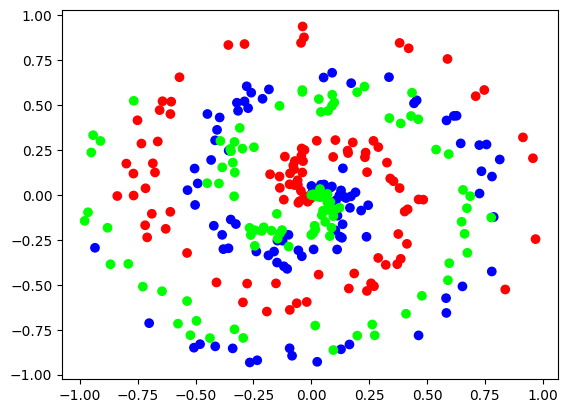

In [28]:
from nnfs.datasets import spiral_data
import numpy as np
import nnfs
nnfs.init()
import matplotlib.pyplot as plt
X, y = spiral_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg')
plt.show()

In [33]:
# Create dataset
X, y = spiral_data(samples=100, classes=3)
# Create a dense laye with 2 inputs and 3 neurons
dense1 = layer_dense(2,3)
# create a relu activation which going to used with dense1
activation1 = Activation_relu()
# create another dense layer with 3 input features(taken from prev layer output)
dense2 = layer_dense(3,3)
# Create Softmax classifier’s combined loss and activation
loss_activation = Activation_softmax_loss_categoricalCrossEntropy()
# Perform a forward pass of our training data through this layer
dense1.forward(X)
# Perfrom a forward pass through ativation function
activation1.forward(dense1.outputs)
# perform a forward pass throught the second dense layer
# which takes prev layer activation function ouput as input
dense2.forward(activation1.outputs)
# Perform a forward pass through the activation/loss function
# takes the output of second dense layer here and returns loss
loss_activation.forward(dense2.outputs,y)

# Let’s see output of the first few samples:
print(loss_activation.output[:5])
# Print loss value
print('loss:', loss)

TypeError: Cannot interpret '3' as a data type

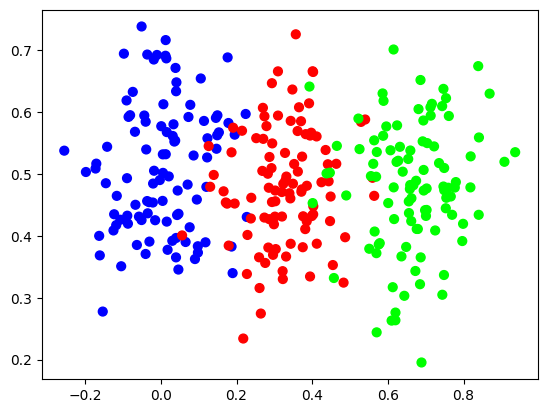

In [2]:
# Simple Dataset
import nnfs
from nnfs.datasets import vertical_data
nnfs.init()
X, y = vertical_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='brg')
plt.show()